In [ ]:
import sys

sys.path.insert(0, "..")

import copy
import itertools
import os
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path

import h5py
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import yaml
from src.data.balloon import (
    CortexLayer,
    HaemodynamicConstants,
    HaemodynamicState,
    simulate_cortex,
)

from scripts.run_sim import init_h5, run_simulation, write_sim

In [ ]:
N_VALUES = 5
N_SAMPLES = 100
BASE_SEED = 42
OUT_DIR = Path("../data/gridsearch")
CONFIG = "../config/simulation-linear.yaml"

# taking 5 values for each param, resulrs in 25 combinations

GRID = {
    "kappa": np.exp(np.linspace(0.65 - 2 * 0.040, 0.65 + 2 * 0.040, N_VALUES)),
    "tau": np.exp(np.linspace(0.98 - 2 * 0.049, 0.98 + 2 * 0.049, N_VALUES)),
}

combos = list(itertools.product(GRID["kappa"], GRID["tau"]))
print(f"{len(combos)} combinations × {N_SAMPLES} samples = {len(combos) * N_SAMPLES} simulations")
print(f"kappa: {GRID['kappa'].round(4)}")
print(f"tau:   {GRID['tau'].round(4)}")

25 combinations × 100 samples = 2500 simulations
kappa: [1.8404 1.8776 1.9155 1.9542 1.9937]
tau:   [2.537  2.6    2.6645 2.7305 2.7983]


In [3]:
# ── Run grid search ────────────────────────────────────────────────────────────

with open(CONFIG) as f:
    base_cfg = yaml.safe_load(f)

OUT_DIR.mkdir(parents=True, exist_ok=True)


def make_cfg(base_cfg, kappa, tau):
    cfg = copy.deepcopy(base_cfg)
    cfg["haemodynamic"]["kappa"] = float(kappa)
    for layer in cfg["simulation"]["layers"]:
        layer["tau"] = float(tau)
    return cfg


def run_combo(args):
    base_cfg, kappa, tau, out_path, base_seed = args
    cfg = make_cfg(base_cfg, kappa, tau)
    seeds = [base_seed + i for i in range(N_SAMPLES)]
    with h5py.File(out_path, "w") as h5f:
        init_h5(h5f, cfg, N_SAMPLES, latent_downsample=1)
        for i, seed in enumerate(seeds):
            write_sim(h5f, i, run_simulation(cfg, seed=seed))
    return out_path


tasks = []
for i, (kappa, tau) in enumerate(combos):
    name = f"kappa{kappa:.4f}_tau{tau:.4f}.h5"
    tasks.append((base_cfg, kappa, tau, str(OUT_DIR / name), BASE_SEED + i * N_SAMPLES))

done = 0
n_workers = min(os.cpu_count() or 4, 8)
with ProcessPoolExecutor(max_workers=n_workers) as pool:
    futures = {pool.submit(run_combo, t): t for t in tasks}
    for fut in as_completed(futures):
        path = fut.result()
        done += 1
        print(f"[{done}/{len(combos)}] {Path(path).name}", flush=True)

print(f"\nDone. {len(combos)} files in {OUT_DIR}/")

[1/25] kappa1.8776_tau2.6645.h5
[2/25] kappa1.8404_tau2.5370.h5
[3/25] kappa1.8776_tau2.6000.h5
[4/25] kappa1.8404_tau2.7983.h5
[5/25] kappa1.8776_tau2.5370.h5
[6/25] kappa1.8404_tau2.7305.h5
[7/25] kappa1.8404_tau2.6645.h5
[8/25] kappa1.8404_tau2.6000.h5
[9/25] kappa1.8776_tau2.7983.h5
[10/25] kappa1.9155_tau2.6000.h5
[11/25] kappa1.9155_tau2.6645.h5
[12/25] kappa1.9155_tau2.7305.h5
[13/25] kappa1.9155_tau2.5370.h5
[14/25] kappa1.8776_tau2.7305.h5
[15/25] kappa1.9155_tau2.7983.h5
[16/25] kappa1.9542_tau2.5370.h5
[17/25] kappa1.9542_tau2.6000.h5
[18/25] kappa1.9542_tau2.7983.h5
[19/25] kappa1.9542_tau2.7305.h5
[20/25] kappa1.9937_tau2.5370.h5
[21/25] kappa1.9937_tau2.6000.h5
[22/25] kappa1.9542_tau2.6645.h5
[23/25] kappa1.9937_tau2.6645.h5
[24/25] kappa1.9937_tau2.7305.h5
[25/25] kappa1.9937_tau2.7983.h5

Done. 25 files in ../data/gridsearch/


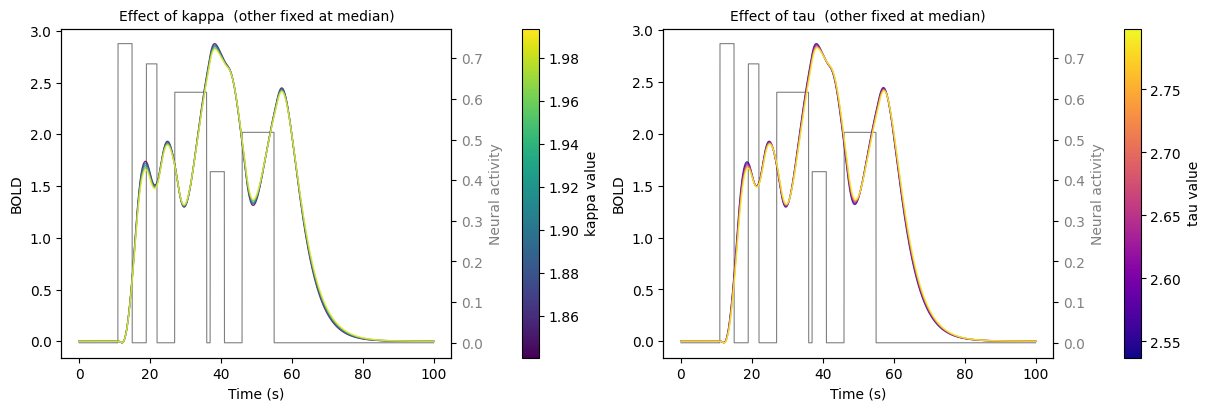

In [4]:
# ── Visualise: same neural input, only parameter changes ──────────────────────

DT = float(base_cfg["simulation"]["dt"])
HAEMO_DT = float(base_cfg["simulation"].get("haemo_dt", DT))
ORDER = base_cfg["simulation"].get("order", "linear")
HAEMO_RATIO = max(1, round(DT / HAEMO_DT))

# Reference file: both params at median
mid = {p: GRID[p][N_VALUES // 2] for p in ["kappa", "tau"]}
ref_name = f"kappa{mid['kappa']:.4f}_tau{mid['tau']:.4f}.h5"
with h5py.File(OUT_DIR / ref_name, "r") as h5f:
    src_pos = h5f["meta"]["source_position"][0]
    x_1d = h5f["layer_0"]["x"][0, :, src_pos[0], src_pos[1]].astype(np.float64)

x_haemo = np.repeat(x_1d, HAEMO_RATIO).reshape(-1, 1, 1)
times = np.arange(len(x_haemo)) * HAEMO_DT


def run_haemo(x_input, kappa, tau, cfg):
    hc = cfg["haemodynamic"]
    ac = cfg["acquisition"]
    D = x_input.shape[1:]
    state = HaemodynamicState(
        x=np.zeros(D), s=np.zeros(D), f=np.ones(D), v=np.ones(D), q=np.ones(D)
    )
    layer = CortexLayer(depth=0, tau=tau, state=state, lambda_d=0.0)
    c = HaemodynamicConstants(
        kappa=kappa,
        gamma=float(hc["gamma"]),
        alpha=float(hc["alpha"]),
        E0=float(hc["E0"]),
        V0=float(hc["V0"]),
    )
    states = simulate_cortex([layer], c, [x_input], dt=HAEMO_DT, tau_d=1.0, order=ORDER)[0]
    eps = float(ac["eps"])
    k1 = 4.3 * float(ac["f0"]) * float(hc["E0"]) * float(ac["TE"])
    k2 = eps * float(ac["r0"]) * float(hc["E0"]) * float(ac["TE"])
    k3 = 1.0 - eps
    v, q = states["v"][:, 0, 0], states["q"][:, 0, 0]
    return float(hc["V0"]) * (k1 * (1 - q) + k2 * (1 - q / v) + k3 * (1 - v))


fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

for ax, param, cmap in zip(axes, ["kappa", "tau"], [plt.cm.viridis, plt.cm.plasma]):
    grid = GRID[param]
    norm = mcolors.Normalize(vmin=grid.min(), vmax=grid.max())

    ax_neural = ax.twinx()
    ax_neural.plot(times, x_haemo[:, 0, 0], color="black", linewidth=0.8, alpha=0.5, label="neural")
    ax_neural.set_ylabel("Neural activity", color="gray")
    ax_neural.tick_params(axis="y", labelcolor="gray")

    for val in grid:
        p = {**mid, param: val}
        bold = run_haemo(x_haemo, kappa=p["kappa"], tau=p["tau"], cfg=base_cfg)
        ax.plot(times, bold, color=cmap(norm(val)), alpha=0.8, linewidth=1.0)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label=f"{param} value")
    ax.set_title(f"Effect of {param}  (other fixed at median)", fontsize=10)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("BOLD")
    ax.set_zorder(ax_neural.get_zorder() + 1)
    ax.patch.set_visible(False)

plt.show()